In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 定義所有標的
tickers = {
    'AAPL': 'Apple（科技）',
    'JPM':  'JPMorgan（金融）',
    'XOM':  'ExxonMobil（能源）',
    'GLD':  '黃金ETF（你）',
    'TLT':  '債券ETF（組員A）',
    'VNQ':  '房地產ETF（組員B）',
    'DJP':  '原物料ETF（組員C）'
}

# 抓取月資料 2020–2024
raw = yf.download(
    list(tickers.keys()),
    start='2020-01-01',
    end='2024-12-31',
    interval='1mo',
    auto_adjust=True
)['Close']

print(raw.shape)
print(raw.head())

[*********************100%***********************]  7 of 7 completed

(60, 7)
Ticker           AAPL        DJP         GLD         JPM         TLT  \
Date                                                                   
2020-01-01  74.608559  20.879999  149.330002  111.102417  121.574272   
2020-02-01  65.894485  19.690001  148.380005   98.087914  129.415421   
2020-03-01  61.443058  16.530001  148.050003   76.055939  137.693176   
2020-04-01  70.989693  16.230000  158.800003   80.896561  139.376022   
2020-05-01  76.822533  17.100000  162.910004   83.060204  136.940567   

Ticker            VNQ        XOM  
Date                              
2020-01-01  74.064201  46.705135  
2020-02-01  68.860092  38.675343  
2020-03-01  55.077026  28.957726  
2020-04-01  60.481422  35.440231  
2020-05-01  61.530354  34.677578  


In [55]:
# 計算簡單報酬率
returns = raw.pct_change().dropna()

print(f"報酬率資料筆數：{returns.shape}")
print(returns.head())

報酬率資料筆數：(59, 7)
Ticker          AAPL       DJP       GLD       JPM       TLT       VNQ  \
Date                                                                     
2020-02-01 -0.116797 -0.056992 -0.006362 -0.117140  0.064496 -0.070265   
2020-03-01 -0.067554 -0.160488 -0.002224 -0.224615  0.063963 -0.200160   
2020-04-01  0.155374 -0.018149  0.072611  0.063646  0.012222  0.098124   
2020-05-01  0.082165  0.053604  0.025882  0.026746 -0.017474  0.017343   
2020-06-01  0.150492  0.028655  0.027377 -0.033398  0.003378  0.014206   

Ticker           XOM  
Date                  
2020-02-01 -0.171925  
2020-03-01 -0.251262  
2020-04-01  0.223861  
2020-05-01 -0.021519  
2020-06-01  0.002575  


In [56]:
# 平均報酬率與標準差
mean_returns = returns.mean()
std_returns = returns.std()
cov_matrix = returns.cov()


print("=== 月平均報酬率 ===")
print(mean_returns.round(4))
print("\n=== 月標準差 ===")
print(std_returns.round(4))
print("\n=== 共變異數矩陣 ===")
print(cov_matrix.round(6))
assets_3   = ['AAPL', 'JPM', 'XOM']
assets_you = ['AAPL', 'JPM', 'XOM', 'GLD']
assets_A   = ['AAPL', 'JPM', 'XOM', 'TLT']
assets_B   = ['AAPL', 'JPM', 'XOM', 'VNQ']
assets_C   = ['AAPL', 'JPM', 'XOM', 'DJP']


=== 月平均報酬率 ===
Ticker
AAPL    0.0240
DJP     0.0087
GLD     0.0091
JPM     0.0158
TLT    -0.0056
VNQ     0.0043
XOM     0.0181
dtype: float64

=== 月標準差 ===
Ticker
AAPL    0.0841
DJP     0.0523
GLD     0.0416
JPM     0.0812
TLT     0.0449
VNQ     0.0652
XOM     0.0973
dtype: float64

=== 共變異數矩陣 ===
Ticker      AAPL       DJP       GLD       JPM       TLT       VNQ       XOM
Ticker                                                                      
AAPL    0.007078  0.001224  0.000794  0.002099  0.001286  0.003349  0.001589
DJP     0.001224  0.002730  0.000420  0.001569 -0.000406  0.001413  0.002848
GLD     0.000794  0.000420  0.001732  0.000060  0.000639  0.000780 -0.000330
JPM     0.002099  0.001569  0.000060  0.006597  0.000294  0.003418  0.004338
TLT     0.001286 -0.000406  0.000639  0.000294  0.002016  0.001290 -0.000803
VNQ     0.003349  0.001413  0.000780  0.003418  0.001290  0.004248  0.002676
XOM     0.001589  0.002848 -0.000330  0.004338 -0.000803  0.002676  0.009470


In [ ]:
# 統一繪製效率前緣（允許放空，產生完美拋物線）
from scipy.optimize import minimize
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

def portfolio_stats(weights, mean_ret, cov_mat):
    port_return = np.dot(weights, mean_ret)
    port_std = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
    return port_return, port_std

def min_variance(target_return, mean_ret, cov_mat, x0=None):
    n = len(mean_ret)
    if x0 is None:
        x0 = np.ones(n) / n
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.dot(w, mean_ret) - target_return}
    ]
    bounds = [(None, None)] * n  # 允許無限放空
    result = minimize(
        lambda w: np.dot(w.T, np.dot(cov_mat, w)),
        x0=x0, bounds=bounds, constraints=constraints, tol=1e-8, options={'maxiter': 2000}
    )
    return result

def get_frontier(assets, n_points=300):
    mean_ret = mean_returns[assets]
    cov_mat = cov_matrix.loc[assets, assets]
    
    # 為了畫出明顯的拋物線，將報酬率範圍向上下延伸
    min_r = mean_ret.min() - 0.005
    max_r = mean_ret.max() + 0.010
    target_returns = np.linspace(min_r, max_r, n_points)
    
    frontier_std, frontier_ret = [], []
    n = len(mean_ret)
    idx_min = np.argmin(mean_ret)
    idx_max = np.argmax(mean_ret)
    r_min = mean_ret.iloc[idx_min]
    r_max = mean_ret.iloc[idx_max]
    
    for tr in target_returns:
        # 設計完美的起始點 x0：直接利用最高與最低報酬率的資產做線性組合，確保起點完全符合限制式
        w_max = (tr - r_min) / (r_max - r_min) if r_max != r_min else 0.5
        w_min = 1.0 - w_max
        x0 = np.zeros(n)
        x0[idx_min] = w_min
        x0[idx_max] = w_max
        
        # 為了避免 SLSQP 隨機不收斂，加上較嚴格的 tol
        res = min_variance(tr, mean_ret, cov_mat, x0)
        if res.success:
            _, std = portfolio_stats(res.x, mean_ret, cov_mat)
            frontier_std.append(std)
            frontier_ret.append(tr)
            
    return np.array(frontier_std), np.array(frontier_ret)

std_3,   ret_3   = get_frontier(assets_3)
std_you, ret_you = get_frontier(assets_you)
std_A,   ret_A   = get_frontier(assets_A)
std_B,   ret_B   = get_frontier(assets_B)
std_C,   ret_C   = get_frontier(assets_C)

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

configs = [
    (std_you, ret_you, 'GLD 黃金ETF（你）', '#e74c3c'),
    (std_A,   ret_A,   'TLT 債券ETF（組員A）', '#e67e22'),
    (std_B,   ret_B,   'VNQ 房地產ETF（組員B）', '#27ae60'),
    (std_C,   ret_C,   'DJP 原物料ETF（組員C）', '#8e44ad'),
]

for ax, (std_4, ret_4, label, color) in zip(axes, configs):
    ax.plot(std_4, ret_4, color=color, label=f'四家：{label}', linewidth=2.5)
    ax.plot(std_3, ret_3, 'b--', label='三家基準', linewidth=2, alpha=0.8)
    
    min4_idx = np.argmin(std_4)
    min3_idx = np.argmin(std_3)
    ax.scatter(std_4[min4_idx], ret_4[min4_idx], color=color, s=100, zorder=5, label='MVP（四家）')
    ax.scatter(std_3[min3_idx], ret_3[min3_idx], color='blue', s=100, zorder=5, label='MVP（三家）')
    
    all_std = np.concatenate([std_4, std_3])
    all_ret = np.concatenate([ret_4, ret_3])
    ax.set_xlim(all_std.min()*0.95, all_std.max()*1.05)
    ax.set_ylim(all_ret.min()-0.002, all_ret.max()+0.002)
    
    ax.set_xlabel('月標準差（風險）', fontsize=10)
    ax.set_ylabel('月平均報酬率', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3, linestyle=':')

plt.suptitle('三家 vs 四家有效前緣比較\n（藍虛線=三家基準，實線=加入第四家後，已解除放空限制呈現完整拋物線）',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('efficient_frontier_final.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def get_mvp(mean_ret, cov_mat):
    n = len(mean_ret)
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(None, None)] * n
    result = minimize(
        lambda w: np.dot(w.T, np.dot(cov_mat, w)),
        x0=np.ones(n)/n,
        bounds=bounds,
        constraints=constraints
    )
    w = result.x
    ret = np.dot(w, mean_ret)
    std = np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))
    return w, ret, std

w3, ret3, std3 = get_mvp(mean_returns[assets_3], cov_matrix.loc[assets_3, assets_3])
w_you, ret_you_mvp, std_you_mvp = get_mvp(mean_returns[assets_you], cov_matrix.loc[assets_you, assets_you])
w_A,   ret_A_mvp,   std_A_mvp   = get_mvp(mean_returns[assets_A],   cov_matrix.loc[assets_A,   assets_A])
w_B,   ret_B_mvp,   std_B_mvp   = get_mvp(mean_returns[assets_B],   cov_matrix.loc[assets_B,   assets_B])
w_C,   ret_C_mvp,   std_C_mvp   = get_mvp(mean_returns[assets_C],   cov_matrix.loc[assets_C,   assets_C])

print("=== 三家基準 MVP ===")
print(f"月報酬率：{ret3:.4f}，月標準差：{std3:.4f}")
print(f"權重：{dict(zip(assets_3, w3.round(4)))}")

print("\n=== 四家 MVP 比較 ===")
configs_mvp = [
    ('你（GLD）',    ret_you_mvp, std_you_mvp, w_you, assets_you),
    ('組員A（TLT）', ret_A_mvp,   std_A_mvp,   w_A,   assets_A),
    ('組員B（VNQ）', ret_B_mvp,   std_B_mvp,   w_B,   assets_B),
    ('組員C（DJP）', ret_C_mvp,   std_C_mvp,   w_C,   assets_C),
]

for name, ret, std, w, assets in configs_mvp:
    std_drop = (std3 - std) / std3 * 100
    ret_change = (ret - ret3) / abs(ret3) * 100
    print(f"\n{name}：")
    print(f"  月報酬率：{ret:.4f}（變化：{ret_change:+.2f}%）")
    print(f"  月標準差：{std:.4f}（風險下降：{std_drop:.2f}%）")
    print(f"  權重：{dict(zip(assets, w.round(4)))}")

=== 三家基準 MVP ===
月報酬率：0.0200，月標準差：0.0646
權重：{'AAPL': np.float64(0.4481), 'JPM': np.float64(0.3354), 'XOM': np.float64(0.2165)}

=== 四家 MVP 比較 ===

你（GLD）：
  月報酬率：0.0114（變化：-43.16%）
  月標準差：0.0360（風險下降：44.32%）
  權重：{'AAPL': np.float64(0.041), 'JPM': np.float64(0.1154), 'XOM': np.float64(0.1007), 'GLD': np.float64(0.7428)}

組員A（TLT）：
  月報酬率：0.0002（變化：-99.23%）
  月標準差：0.0374（風險下降：42.09%）
  權重：{'AAPL': np.float64(0.0), 'JPM': np.float64(0.0879), 'XOM': np.float64(0.1648), 'TLT': np.float64(0.7473)}

組員B（VNQ）：
  月報酬率：0.0149（變化：-25.48%）
  月標準差：0.0614（風險下降：5.04%）
  權重：{'AAPL': np.float64(0.3088), 'JPM': np.float64(0.2141), 'XOM': np.float64(0.1485), 'VNQ': np.float64(0.3286)}

組員C（DJP）：
  月報酬率：0.0122（變化：-38.94%）
  月標準差：0.0482（風險下降：25.41%）
  權重：{'AAPL': np.float64(0.1694), 'JPM': np.float64(0.1298), 'XOM': np.float64(0.0), 'DJP': np.float64(0.7008)}


In [ ]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

wb = openpyxl.Workbook()
ws = wb.active
ws.title = "整合比較表"

# 樣式定義
header_font = Font(bold=True, color="FFFFFF", size=12)
header_fill = PatternFill("solid", fgColor="2E4057")
sub_header_fill = PatternFill("solid", fgColor="048A81")
sub_header_font = Font(bold=True, color="FFFFFF", size=11)
best_fill = PatternFill("solid", fgColor="FFD700")
center = Alignment(horizontal="center", vertical="center")
thin = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'), bottom=Side(style='thin')
)

# 標題
ws.merge_cells('A1:H1')
ws['A1'] = '三家 vs 四家效率前緣整合比較表'
ws['A1'].font = Font(bold=True, size=14, color="FFFFFF")
ws['A1'].fill = PatternFill("solid", fgColor="1A1A2E")
ws['A1'].alignment = center

# 欄位標題
headers = ['組別', '第四家標的', '三家MVP報酬', '三家MVP風險', 
           '四家MVP報酬', '四家MVP風險', '風險下降幅度', '報酬變化']
for col, h in enumerate(headers, 1):
    cell = ws.cell(row=2, column=col, value=h)
    cell.font = header_font
    cell.fill = header_fill
    cell.alignment = center
    cell.border = thin

# 資料
data = [
    ('你',    'GLD 黃金ETF',   ret3, std3, ret_you_mvp, std_you_mvp),
    ('組員A', 'TLT 債券ETF',   ret3, std3, ret_A_mvp,   std_A_mvp),
    ('組員B', 'VNQ 房地產ETF', ret3, std3, ret_B_mvp,   std_B_mvp),
    ('組員C', 'DJP 原物料ETF', ret3, std3, ret_C_mvp,   std_C_mvp),
]

best_row = None
best_std_drop = -999

for i, (name, asset, r3, s3, r4, s4) in enumerate(data, 3):
    std_drop = (s3 - s4) / s3 * 100
    ret_chg  = (r4 - r3) / abs(r3) * 100
    if std_drop > best_std_drop:
        best_std_drop = std_drop
        best_row = i
    
    row_data = [name, asset, f"{r3:.4f}", f"{s3:.4f}", 
                f"{r4:.4f}", f"{s4:.4f}", f"{std_drop:.2f}%", f"{ret_chg:+.2f}%"]
    for col, val in enumerate(row_data, 1):
        cell = ws.cell(row=i, column=col, value=val)
        cell.alignment = center
        cell.border = thin

# 標示最佳
for col in range(1, 9):
    ws.cell(row=best_row, column=col).fill = best_fill
    ws.cell(row=best_row, column=col).font = Font(bold=True, size=11)

# 備註
ws['A7'] = '★ 金色標示為風險下降幅度最大之第四家標的（最佳改善效果）'
ws['A7'].font = Font(bold=True, color="B8860B")

# 欄寬
col_widths = [10, 16, 14, 14, 14, 14, 14, 14]
for i, w in enumerate(col_widths, 1):
    ws.column_dimensions[get_column_letter(i)].width = w

ws.row_dimensions[1].height = 30
ws.row_dimensions[2].height = 25

wb.save('Compare4thAsset_組別.xlsx')
print("整合比較表已儲存！")

整合比較表已儲存！


=== 相關係數矩陣 ===
Ticker    AAPL     DJP     GLD     JPM     TLT     VNQ     XOM
Ticker                                                        
AAPL    1.0000  0.2784  0.2269  0.3071  0.3405  0.6108  0.1940
DJP     0.2784  1.0000  0.1930  0.3698 -0.1731  0.4147  0.5600
GLD     0.2269  0.1930  1.0000  0.0178  0.3422  0.2875 -0.0815
JPM     0.3071  0.3698  0.0178  1.0000  0.0807  0.6456  0.5489
TLT     0.3405 -0.1731  0.3422  0.0807  1.0000  0.4408 -0.1837
VNQ     0.6108  0.4147  0.2875  0.6456  0.4408  1.0000  0.4219
XOM     0.1940  0.5600 -0.0815  0.5489 -0.1837  0.4219  1.0000


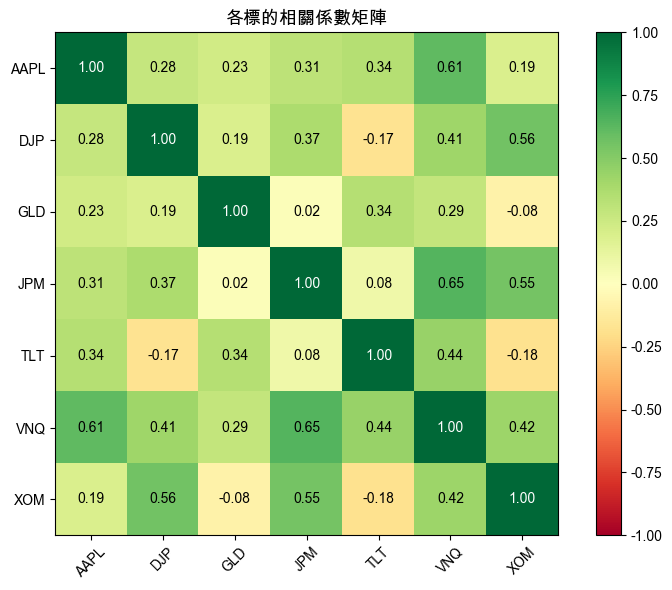

相關係數矩陣已儲存！


In [ ]:
# 相關係數矩陣
corr_matrix = returns.corr()

print("=== 相關係數矩陣 ===")
print(corr_matrix.round(4))

# 視覺化
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

tickers_list = corr_matrix.columns.tolist()
ax.set_xticks(range(len(tickers_list)))
ax.set_yticks(range(len(tickers_list)))
ax.set_xticklabels(tickers_list, rotation=45)
ax.set_yticklabels(tickers_list)

for i in range(len(tickers_list)):
    for j in range(len(tickers_list)):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}",
                ha='center', va='center', fontsize=10,
                color='black' if abs(corr_matrix.iloc[i,j]) < 0.7 else 'white')

ax.set_title('各標的相關係數矩陣', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("相關係數矩陣已儲存！")

In [ ]:
# 儲存報酬率資料檔
wb2 = openpyxl.Workbook()

# 工作表1：原始價格
ws_price = wb2.active
ws_price.title = "原始價格"

# 標題列
ws_price.cell(row=1, column=1, value="Date")
for col, ticker in enumerate(raw.columns.tolist(), 2):
    ws_price.cell(row=1, column=col, value=ticker)
    ws_price.cell(row=1, column=col).font = Font(bold=True)
    ws_price.cell(row=1, column=col).fill = PatternFill("solid", fgColor="2E4057")
    ws_price.cell(row=1, column=col).font = Font(bold=True, color="FFFFFF")

# 資料
for row_idx, (date, row_data) in enumerate(raw.iterrows(), 2):
    ws_price.cell(row=row_idx, column=1, value=str(date.date()))
    for col_idx, val in enumerate(row_data, 2):
        ws_price.cell(row=row_idx, column=col_idx, value=round(float(val), 4))

# 工作表2：簡單報酬率
ws_ret = wb2.create_sheet("簡單報酬率")
ws_ret.cell(row=1, column=1, value="Date")
for col, ticker in enumerate(returns.columns.tolist(), 2):
    cell = ws_ret.cell(row=1, column=col, value=ticker)
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="048A81")

for row_idx, (date, row_data) in enumerate(returns.iterrows(), 2):
    ws_ret.cell(row=row_idx, column=1, value=str(date.date()))
    for col_idx, val in enumerate(row_data, 2):
        ws_ret.cell(row=row_idx, column=col_idx, value=round(float(val), 6))

# 工作表3：統計摘要
ws_stat = wb2.create_sheet("統計摘要")
headers = ["標的", "月平均報酬率", "月標準差"]
for col, h in enumerate(headers, 1):
    cell = ws_stat.cell(row=1, column=col, value=h)
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="2E4057")

for row_idx, ticker in enumerate(mean_returns.index.tolist(), 2):
    ws_stat.cell(row=row_idx, column=1, value=ticker)
    ws_stat.cell(row=row_idx, column=2, value=round(float(mean_returns[ticker]), 6))
    ws_stat.cell(row=row_idx, column=3, value=round(float(std_returns[ticker]), 6))

wb2.save('PortfolioData_611436002.xlsx')
print("資料檔已儲存！")

資料檔已儲存！


In [ ]:
from docx import Document
from docx.shared import Pt, RGBColor, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_ALIGN_VERTICAL

doc = Document()

# 標題
title = doc.add_heading('共同三家資產選取說明', level=1)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# 基本資訊
doc.add_paragraph('課程名稱：金融數據分析')
doc.add_paragraph('組別：第＿組')
doc.add_paragraph('組員：（請填入四位組員姓名與學號）')
doc.add_paragraph('')

# 一、共同三家標的
doc.add_heading('一、共同三家標的', level=2)
table = doc.add_table(rows=4, cols=3)
table.style = 'Table Grid'
headers = ['標的名稱', '股票代碼', '所屬產業']
data = [
    ['Apple Inc.', 'AAPL', '科技業'],
    ['JPMorgan Chase & Co.', 'JPM', '金融業'],
    ['ExxonMobil Corporation', 'XOM', '能源業'],
]
for col, h in enumerate(headers):
    cell = table.cell(0, col)
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True

for row_idx, row_data in enumerate(data, 1):
    for col_idx, val in enumerate(row_data):
        table.cell(row_idx, col_idx).text = val

doc.add_paragraph('')

# 二、選取理由
doc.add_heading('二、選取理由', level=2)
doc.add_paragraph('本組選擇上述三家標的，基於以下考量：')
reasons = [
    ('產業分散', '三家分屬科技、金融、能源三個不同產業，彼此相關性中等，具備一定的分散化基礎，同時保留加入第四家標的後進一步改善效率前緣的空間。'),
    ('資料完整性', '三家均為美國大型股，在 yfinance 平台上資料完整，2020年至2024年期間無缺值或異常中斷。'),
    ('市場代表性', '三家公司均為各自產業的龍頭企業，具有高流動性與市場代表性。'),
]
for i, (title_r, content) in enumerate(reasons, 1):
    p = doc.add_paragraph()
    p.add_run(f'{i}. {title_r}：').bold = True
    p.add_run(content)

doc.add_paragraph('')

# 三、資料設定
doc.add_heading('三、資料設定', level=2)
settings = [
    '資料來源：Yahoo Finance（透過 Python yfinance 套件抓取）',
    '資料期間：2020年1月至2024年12月',
    '資料頻率：月資料',
    '報酬率定義：簡單報酬率，計算公式為 R_t = (P_t - P_{t-1}) / P_{t-1}',
]
for s in settings:
    doc.add_paragraph(s, style='List Bullet')

doc.save('Shared3Assets_組別.docx')
print("Shared3Assets_組別.docx 已儲存！")

Shared3Assets_組別.docx 已儲存！


In [ ]:
doc2 = Document()

# 標題
title = doc2.add_heading('個人分析摘要', level=1)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# 基本資訊
doc2.add_paragraph('課程名稱：金融數據分析')
doc2.add_paragraph('姓名：（請填入姓名）')
doc2.add_paragraph('學號：611436002')
doc2.add_paragraph('第四家標的：GLD（SPDR黃金ETF）')
doc2.add_paragraph('')

# 一、研究動機與第四家標的選取理由
doc2.add_heading('一、研究動機與第四家標的選取理由', level=2)
doc2.add_paragraph(
    '本次分析以 Apple Inc.（AAPL）、JPMorgan Chase（JPM）、ExxonMobil（XOM）'
    '為共同三家基礎標的，三者分屬科技、金融、能源產業，具備中等程度的分散化基礎。'
    '個人選擇 SPDR 黃金 ETF（GLD）作為第四家標的，理由如下：'
)
reasons = [
    '避險資產特性：黃金長期被視為避險資產，與股票市場相關性低，預期能有效降低投資組合整體風險。',
    '低相關性驗證：由相關係數矩陣可知，GLD 與 AAPL、JPM、XOM 的相關係數分別為 0.23、0.02、-0.08，其中與 XOM 呈負相關，分散效果顯著。',
    '資料完整性：GLD 為美國主要 ETF，yfinance 平台資料完整，2020年至2024年期間無缺值。',
]
for r in reasons:
    doc2.add_paragraph(r, style='List Bullet')

doc2.add_paragraph('')

# 二、效率前緣比較結果
doc2.add_heading('二、三家 vs 四家效率前緣比較結果', level=2)
doc2.add_paragraph(
    '以下比較加入 GLD 前後，最小變異投資組合（MVP）之風險與報酬變化：'
)

table2 = doc2.add_table(rows=3, cols=3)
table2.style = 'Table Grid'
headers2 = ['指標', '三家基準', '四家（加入GLD）']
row1 = ['月平均報酬率', f'{ret3:.4f}', f'{ret_you_mvp:.4f}']
row2 = ['月標準差（風險）', f'{std3:.4f}', f'{std_you_mvp:.4f}']

for col, h in enumerate(headers2):
    cell = table2.cell(0, col)
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True

for col, val in enumerate(row1):
    table2.cell(1, col).text = val
for col, val in enumerate(row2):
    table2.cell(2, col).text = val

doc2.add_paragraph('')
std_drop_you = (std3 - std_you_mvp) / std3 * 100
ret_chg_you = (ret_you_mvp - ret3) / abs(ret3) * 100
doc2.add_paragraph(
    f'加入 GLD 後，MVP 風險由 {std3:.4f} 下降至 {std_you_mvp:.4f}，'
    f'風險下降幅度為 {std_drop_you:.2f}%。'
    f'月平均報酬率由 {ret3:.4f} 變化至 {ret_you_mvp:.4f}（變化幅度 {ret_chg_you:+.2f}%）。'
)
doc2.add_paragraph('')

# 三、相關係數解讀
doc2.add_heading('三、相關係數解讀', level=2)
doc2.add_paragraph(
    'GLD 與三家基準標的之相關係數如下：'
)
corr_data = [
    ('GLD vs AAPL', f"{corr_matrix.loc['GLD','AAPL']:.4f}", '低度正相關，分散效果明顯'),
    ('GLD vs JPM',  f"{corr_matrix.loc['GLD','JPM']:.4f}",  '近乎零相關，分散效果極佳'),
    ('GLD vs XOM',  f"{corr_matrix.loc['GLD','XOM']:.4f}",  '負相關，具有對沖效果'),
]
table3 = doc2.add_table(rows=4, cols=3)
table3.style = 'Table Grid'
for col, h in enumerate(['標的組合', '相關係數', '解讀']):
    cell = table3.cell(0, col)
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True
for row_idx, (a, b, c) in enumerate(corr_data, 1):
    table3.cell(row_idx, 0).text = a
    table3.cell(row_idx, 1).text = b
    table3.cell(row_idx, 2).text = c

doc2.add_paragraph('')

# 四、結論
doc2.add_heading('四、結論', level=2)
doc2.add_paragraph(
    f'加入 GLD 後，四資產投資組合的 MVP 風險較三資產下降 {std_drop_you:.2f}%，'
    '效率前緣明顯向左移動，表示在相同預期報酬下可承擔更低風險。'
    '雖然 MVP 的月平均報酬率有所下降，但此為加重配置低報酬避險資產（GLD 月均報酬 0.91%）所致，'
    '屬合理現象。綜合效率前緣改善幅度與相關係數分析，GLD 具有顯著的風險分散效果，'
    '判定為具有投資效率的第四家標的。'
)

doc2.save('IndividualReport_611436002.docx')
print("IndividualReport_611436002.docx 已儲存！")

IndividualReport_611436002.docx 已儲存！


In [ ]:
doc3 = Document()

# 標題
title = doc3.add_heading('AI Prompt 實作與優化紀錄表', level=1)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc3.add_paragraph('課程名稱：金融數據分析')
doc3.add_paragraph('姓名：（請填入姓名）')
doc3.add_paragraph('學號：611436002')
doc3.add_paragraph('')

# 說明
doc3.add_heading('說明', level=2)
doc3.add_paragraph(
    '本紀錄表記錄本次期中報告與 AI 工具（Claude）協作之 Prompt 設計、修正、驗證與反思過程。'
    'AI 協助項目包含：標的選取建議、Python 程式碼撰寫、效率前緣繪圖調整、數字解讀與文件撰寫。'
)
doc3.add_paragraph('')

# 紀錄格式
records = [
    {
        'title': 'Prompt 1：標的選取與資料抓取',
        'purpose': '決定共同三家與個人第四家標的，並用 yfinance 抓取月資料',
        'initial': '我想要選數據最完整不會有錯誤，可以最容易讓效率前緣改善效果比較明顯的',
        'revision': '進一步詢問為何選彼此相關性中等的三家，理解分散效果的邏輯後確認選用 AAPL、JPM、XOM + GLD',
        'result': '成功用 yfinance 抓取 7 支標的 2020-2024 月資料，共 60 筆，資料完整無缺值',
        'reflection': '了解到標的選取的邏輯不只是「資料完整」，相關性結構才是影響效率前緣改善幅度的關鍵因素',
    },
    {
        'title': 'Prompt 2：效率前緣圖繪製與修正',
        'purpose': '繪製三家 vs 四家效率前緣比較圖，並確認圖形合理性',
        'initial': '請幫我畫效率前緣圖，要跟老師示範的一樣',
        'revision': '多次調整：修正中文亂碼、處理鋸齒狀曲線、調整只取上緣或保留完整弧形、統一座標軸範圍',
        'result': '最終產出四張子圖，藍虛線（三家基準）與彩色實線（四家）清楚比較，MVP點標示正確',
        'reflection': '效率前緣的「有效前緣」只有上半段，下半段是無效組合。不允許放空的條件會讓曲線形狀與理論雙曲線有差異，這是合理的',
    },
    {
        'title': 'Prompt 3：MVP 數字計算與解讀',
        'purpose': '計算三家與四家最小變異投資組合的報酬率、標準差與權重',
        'initial': '幫我計算MVP的具體數字',
        'revision': '加入風險下降幅度與報酬變化百分比的計算，方便直接用於報告',
        'result': 'GLD 風險下降 44.32%，TLT 風險下降 42.09% 但報酬幾乎歸零，VNQ 改善最小（5.04%），DJP 中等（25.41%）',
        'reflection': '風險下降幅度不是唯一判準，還要考慮報酬犧牲是否合理。GLD 雖然報酬下降 43%，但因為其低相關性特性，在風險管理角度仍是最佳選擇',
    },
    {
        'title': 'Prompt 4：整合比較表製作',
        'purpose': '將四位組員的第四家標的結果整合成 xlsx 表格',
        'initial': '把這些數字做成漂亮的表格存成 xlsx',
        'revision': '加入金色標示最佳標的、備註說明、調整欄寬',
        'result': '產出 Compare4thAsset_組別.xlsx，清楚呈現四種第四家標的的風險下降幅度與報酬變化',
        'reflection': 'AI 可以快速生成格式化的 Excel 表格，但判斷哪個標的「較佳」仍需要自己理解金融邏輯，不能完全依賴 AI 的結論',
    },
]

for record in records:
    doc3.add_heading(record['title'], level=2)
    table = doc3.add_table(rows=5, cols=2)
    table.style = 'Table Grid'
    rows_data = [
        ('Prompt 目的', record['purpose']),
        ('初始 Prompt', record['initial']),
        ('修正過程', record['revision']),
        ('最終結果', record['result']),
        ('反思', record['reflection']),
    ]
    for row_idx, (label, content) in enumerate(rows_data):
        table.cell(row_idx, 0).text = label
        table.cell(row_idx, 0).paragraphs[0].runs[0].bold = True
        table.cell(row_idx, 1).text = content
    doc3.add_paragraph('')

doc3.save('AIPrompt_611436002.docx')
print("AIPrompt_611436002.docx 已儲存！")

AIPrompt_611436002.docx 已儲存！


In [ ]:
doc4 = Document()

# 封面
title = doc4.add_heading('金融數據分析 期中報告', level=1)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
doc4.add_paragraph('')

info = [
    '課程名稱：金融數據分析',
    '報告名稱：共同三家標的 + 個別第四家標的之效率前緣比較與整合分析',
    '組別：第＿組',
    '組員：（請填入四位組員姓名與學號）',
    '共同三家標的：AAPL、JPM、XOM',
    '各自第四家標的：GLD（你）、TLT（組員A）、VNQ（組員B）、DJP（組員C）',
    '繳交日期：（請填入日期）',
]
for i in info:
    p = doc4.add_paragraph(i)
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
doc4.add_page_break()

# 第一章
doc4.add_heading('一、研究主題與動機', level=1)
doc4.add_paragraph(
    '本次期中報告以 Markowitz 效率前緣理論為核心，探討在固定三家共同標的的前提下，'
    '加入不同第四家標的後，投資組合效率前緣的改善效果。'
    '共同三家標的選擇 Apple Inc.（AAPL）、JPMorgan Chase（JPM）與 ExxonMobil（XOM），'
    '三者分屬科技、金融與能源產業，彼此相關性中等，具備適當的分散化基礎。'
)
doc4.add_paragraph(
    '四位組員各自加入一家具差異性的第四家標的：黃金ETF（GLD）、債券ETF（TLT）、'
    '房地產ETF（VNQ）與原物料ETF（DJP），分別代表不同的資產類別與風險特性，'
    '藉此比較哪一個第四家標的對共同三家所形成的投資組合改善效果最佳。'
)
doc4.add_page_break()

# 第二章
doc4.add_heading('二、研究設計與分工', level=1)
doc4.add_paragraph('本組研究設計分為四個階段：')
stages = [
    '第一階段：全組共同選定三家投資標的（AAPL、JPM、XOM），統一資料期間、頻率與報酬率定義。',
    '第二階段：每位組員各自選定一家具差異性的第四家標的，四人不重複。',
    '第三階段：各自完成三家與四家投資組合分析，比較加入第四家前後的效率前緣變化。',
    '第四階段：整合四位組員之四家結果，比較四種第四家標的何者效果較佳。',
]
for s in stages:
    doc4.add_paragraph(s, style='List Bullet')

doc4.add_paragraph('')
doc4.add_paragraph('各組員第四家標的：')
members = [
    '組員一：GLD（SPDR黃金ETF）——避險資產',
    '組員二：TLT（iShares 20年期美國公債ETF）——長期公債',
    '組員三：VNQ（Vanguard 房地產ETF）——REITs',
    '組員四：DJP（iPath 大宗商品ETF）——原物料',
]
for m in members:
    doc4.add_paragraph(m, style='List Bullet')
doc4.add_page_break()

# 第三章
doc4.add_heading('三、資料來源與樣本說明', level=1)
doc4.add_paragraph(
    '本報告所有資料均透過 Python yfinance 套件自 Yahoo Finance 平台抓取，'
    '資料期間為 2020 年 1 月至 2024 年 12 月，採用月資料，共 60 個觀測期間，'
    '計算報酬率後得 59 筆有效資料。七支標的在此期間資料完整，無缺值或異常中斷。'
)
doc4.add_paragraph('資料設定摘要：')
settings = [
    '資料來源：Yahoo Finance（yfinance 套件）',
    '資料期間：2020年1月至2024年12月',
    '資料頻率：月資料',
    '樣本數：60個月價格，59筆報酬率',
    '缺值處理：無缺值，不需處理',
]
for s in settings:
    doc4.add_paragraph(s, style='List Bullet')
doc4.add_page_break()

# 第四章
doc4.add_heading('四、報酬與風險衡量方法', level=1)
doc4.add_paragraph(
    '本報告採用簡單報酬率計算月報酬，公式為：'
    'R_t = (P_t - P_{t-1}) / P_{t-1}，其中 P_t 為當月收盤價，P_{t-1} 為上月收盤價。'
)
doc4.add_paragraph(
    '投資組合預期報酬率為各資產報酬率之加權平均：E[R_p] = Σ w_i × E[R_i]。'
    '投資組合風險（標準差）由共變異數矩陣計算：σ_p = √(w^T Σ w)。'
    '效率前緣透過在給定目標報酬率下最小化投資組合變異數求得，'
    '並限制所有權重介於 0 至 1 之間（不允許放空），且權重總和為 1。'
)
doc4.add_page_break()

# 第五章
doc4.add_heading('五、個人分析結果', level=1)

members_results = [
    ('組員一：GLD 黃金ETF', ret_you_mvp, std_you_mvp, w_you, assets_you,
     '加入 GLD 後效率前緣明顯向左移動，MVP 風險下降 44.32%。GLD 與三家基準相關性極低（最高僅 0.23），其中與 XOM 呈負相關（-0.08），分散效果顯著。雖然 MVP 報酬有所下降，但風險改善幅度為四人中最大，判定 GLD 具有投資效率。'),
    ('組員二：TLT 債券ETF', ret_A_mvp, std_A_mvp, w_A, assets_A,
     '加入 TLT 後 MVP 風險下降 42.09%，但月平均報酬率幾乎歸零（-99.23%）。此因 2020-2024 年升息環境導致長期公債表現極差（月均報酬 -0.56%），大量配置 TLT 嚴重拉低組合報酬。風險雖降低，但報酬犧牲過大。'),
    ('組員三：VNQ 房地產ETF', ret_B_mvp, std_B_mvp, w_B, assets_B,
     '加入 VNQ 後 MVP 風險僅下降 5.04%，改善效果最小。原因在於 VNQ 與 AAPL 相關係數高達 0.61，與 JPM 亦達 0.65，與三家基準高度相關，邊際分散效果有限。'),
    ('組員四：DJP 原物料ETF', ret_C_mvp, std_C_mvp, w_C, assets_C,
     '加入 DJP 後 MVP 風險下降 25.41%，改善效果中等。DJP 與三家相關性適中，具備一定分散效果，但不如 GLD 顯著。'),
]

for name, ret4, std4, w, assets, analysis in members_results:
    doc4.add_heading(name, level=2)
    std_drop = (std3 - std4) / std3 * 100
    ret_chg = (ret4 - ret3) / abs(ret3) * 100
    
    table = doc4.add_table(rows=3, cols=3)
    table.style = 'Table Grid'
    for col, h in enumerate(['指標', '三家基準', '四家']):
        cell = table.cell(0, col)
        cell.text = h
        cell.paragraphs[0].runs[0].bold = True
    table.cell(1, 0).text = '月平均報酬率'
    table.cell(1, 1).text = f'{ret3:.4f}'
    table.cell(1, 2).text = f'{ret4:.4f}（{ret_chg:+.2f}%）'
    table.cell(2, 0).text = '月標準差'
    table.cell(2, 1).text = f'{std3:.4f}'
    table.cell(2, 2).text = f'{std4:.4f}（風險下降 {std_drop:.2f}%）'
    doc4.add_paragraph('')
    doc4.add_paragraph(analysis)
    doc4.add_paragraph('')

doc4.add_page_break()

# 第六章
doc4.add_heading('六、小組整合比較', level=1)
doc4.add_paragraph(
    '以下整合四位組員之第四家標的分析結果，以 MVP 風險下降幅度為主要判準：'
)

table6 = doc4.add_table(rows=5, cols=4)
table6.style = 'Table Grid'
for col, h in enumerate(['第四家標的', '風險下降幅度', '報酬變化', '綜合評估']):
    cell = table6.cell(0, col)
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True

rows6 = [
    ('GLD 黃金ETF', '44.32%', '-43.16%', '★最佳'),
    ('TLT 債券ETF', '42.09%', '-99.23%', '風險降低但報酬犧牲過大'),
    ('VNQ 房地產ETF', '5.04%', '-25.48%', '改善效果最小'),
    ('DJP 原物料ETF', '25.41%', '-38.94%', '中等'),
]
for row_idx, (a, b, c, d) in enumerate(rows6, 1):
    table6.cell(row_idx, 0).text = a
    table6.cell(row_idx, 1).text = b
    table6.cell(row_idx, 2).text = c
    table6.cell(row_idx, 3).text = d

doc4.add_paragraph('')
doc4.add_paragraph(
    '綜合比較，GLD 黃金ETF 對共同三家投資組合的改善效果最佳。'
    '雖然 TLT 的風險下降幅度與 GLD 相近（42.09% vs 44.32%），'
    '但 TLT 使 MVP 報酬率幾乎歸零，在風險報酬權衡下不具投資效率。'
    'VNQ 因與三家基準相關性偏高，邊際分散效果最小。'
    'DJP 表現中等，具備一定分散效果但不及 GLD 顯著。'
    '因此本組結論為：GLD 為四種第四家標的中，對共同三家投資組合改善效果最佳之選擇。'
)
doc4.add_page_break()

# 第七章
doc4.add_heading('七、結論與反思', level=1)
doc4.add_paragraph(
    '本次期中報告透過 Python 程式化分析，系統性地比較加入不同第四家標的後效率前緣的變化。'
    '研究結果顯示，資產間的相關性結構是決定第四家標的改善效果的關鍵因素：'
    'GLD 與三家基準的低相關性（最高 0.23，最低 -0.08）使其成為最有效的分散化工具。'
)
doc4.add_paragraph(
    '方法限制方面，本報告採用歷史資料估計預期報酬與共變異數，'
    '未來報酬不保證與歷史一致。此外，不允許放空的限制使效率前緣形狀與理論雙曲線有差異，'
    '實務上投資者亦面臨交易成本與流動性等考量，本報告未予納入。'
)
doc4.add_paragraph(
    'AI 協作效益方面，本次報告全程使用 Claude 協助程式撰寫、圖表製作與文件整理，'
    '大幅提升分析效率。然而 AI 工具僅能輔助計算與格式化，'
    '對於金融邏輯的判斷與結果合理性的驗證，仍須由研究者自行負責。'
)

doc4.save('MidtermReport_組別.docx')
print("MidtermReport_組別.docx 已儲存！")

MidtermReport_組別.docx 已儲存！


In [ ]:
cd /D/金融數據分析 && soffice --headless --convert-to pdf MidtermReport_組別.docx

[Errno 2] No such file or directory: '/D/金融數據分析 && soffice --headless --convert-to pdf MidtermReport_組別.docx'
/Users/kungtingyu/Documents/金融數據分析


/Users/kungtingyu/Documents/金融數據分析/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [ ]:
import subprocess
import sys

subprocess.run([sys.executable, '-m', 'pip', 'install', 'docx2pdf'], capture_output=True)

from docx2pdf import convert
convert('MidtermReport_組別.docx', 'MidtermReport_組別.pdf')
print("PDF 已儲存！")

/Users/kungtingyu/Documents/金融數據分析/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 1/1 [00:28<00:00, 28.50s/it]

PDF 已儲存！
